###Implementacion Algoritmo Perceptón Simple (datos + while)

In [ ]:
import numpy as np

def activacion(h):
    return 1 if h >= 0 else -1

i = 0
eta = 0.1 # Reducimos la tasa de aprendizaje para ver más iteraciones

# XOR
#x_original = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]]) # 4 muestras para XOR
#y = np.array([-1, 1, 1, -1]) # Salidas esperadas para XOR

# AND
x_original = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]]) #4 muestras
y = np.array([-1, -1, -1, 1]) #Para 4 muestras

if np.array_equal(y, np.array([-1, 1, 1, -1])):
    nombre_compuerta = "XOR"
elif np.array_equal(y, np.array([-1, -1, -1, 1])):
    nombre_compuerta = "AND"
else:
    nombre_compuerta = "Desconocido"

p = len(x_original)
cota = 100
historial_error = []

bias_columna = np.ones((p, 1))
x = np.hstack((x_original, bias_columna))
w = np.zeros(x.shape[1])

error_min = p
w_min = np.copy(w)

error_global = 0
for j in range(p):
    h_example = np.dot(x[j], w)
    O_example = activacion(h_example)
    if O_example != y[j]:
        error_global += 1
error = error_global
historial_error.append(error)

if error < error_min:
    error_min = error
    w_min = np.copy(w)

while error > 0 and i < cota:
    ix = np.random.randint(0, p)
    x_actual = x[ix]
    h = np.dot(x_actual, w)
    O = activacion(h)

    error_simple = y[ix] - O
    w = w + eta * error_simple * x_actual
    i += 1

    error_global = 0
    for j in range(p):
        h_example = np.dot(x[j], w)
        O_example = activacion(h_example)
        if O_example != y[j]:
            error_global += 1

    error = error_global
    historial_error.append(error)

    if error < error_min:
        error_min = error
        w_min = np.copy(w)

    print(f"Iteración {i}: Pesos w = {w.round(2)}") # Agregamos esta línea para ver la evolución de w

    if error == 0:
        break

Iteración 1: Pesos w = [0. 0. 0.]
Iteración 2: Pesos w = [-0.2  0.2 -0.2]
Iteración 3: Pesos w = [ 0.   0.  -0.4]
Iteración 4: Pesos w = [ 0.   0.  -0.4]
Iteración 5: Pesos w = [ 0.2  0.2 -0.2]


### Resultados del Entrenamiento

Mejor Error encontrado: 0
Pesos finales (incluyendo sesgo): [ 0.2  0.2 -0.2]
Número de iteraciones para aprender: 5


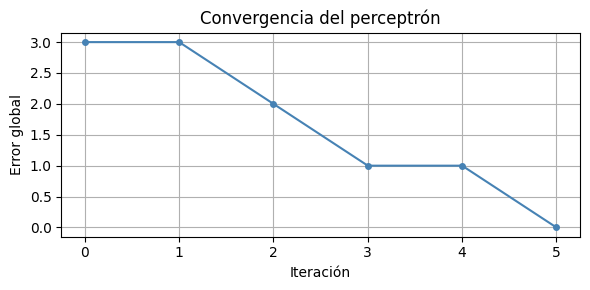

In [ ]:
import matplotlib.pyplot as plt
#Muestra número total de muestras que el perceptrón clasificó mal en cada iteración
print(f"Mejor Error encontrado: {error_min}")
print(f"Pesos finales (incluyendo sesgo): {w_min}")
print(f"Número de iteraciones para aprender: {i}")

plt.figure(figsize=(6, 3))
plt.plot(historial_error, marker='o', markersize=4, color='steelblue')
plt.xlabel('Iteración')
plt.ylabel('Error global')
plt.title('Convergencia del perceptrón')
plt.grid(True)
plt.tight_layout()
plt.show()

### Probando el Perceptrón Entrenado

In [ ]:
print("\n--- Clasificación con los pesos óptimos (w_min) ---")
predictions = []
for k in range(p):
    h_test = np.dot(x[k], w_min)
    O_test = activacion(h_test) # Usar la misma función de activación que en el entrenamiento
    predictions.append(O_test)
    print(f"Entrada: {x_original[k]} (con sesgo: {x[k]}) -> Salida Esperada: {y[k]}, Salida Perceptrón: {O_test}")

# Comparar las predicciones con los valores reales
correct_predictions = np.sum(np.array(predictions) == y)
accuracy = (correct_predictions / p) * 100
print(f"\nNúmero de predicciones correctas: {correct_predictions} de {p}")
print(f"Precisión del modelo: {accuracy:.2f}%")

if error_min == 0:
    print("El Perceptrón ha aprendido la función perfectamente (error global = 0).")
else:
    print(f"El Perceptrón no logró converger a un error de 0. El mejor error global fue {error_min}.")


--- Clasificación con los pesos óptimos (w_min) ---
Entrada: [-1 -1] (con sesgo: [-1. -1.  1.]) -> Salida Esperada: -1, Salida Perceptrón: -1
Entrada: [-1  1] (con sesgo: [-1.  1.  1.]) -> Salida Esperada: -1, Salida Perceptrón: -1
Entrada: [ 1 -1] (con sesgo: [ 1. -1.  1.]) -> Salida Esperada: -1, Salida Perceptrón: -1
Entrada: [1 1] (con sesgo: [1. 1. 1.]) -> Salida Esperada: 1, Salida Perceptrón: 1

Número de predicciones correctas: 4 de 4
Precisión del modelo: 100.00%
El Perceptrón ha aprendido la función perfectamente (error global = 0).


### "Visualización — Frontera de Decisión"




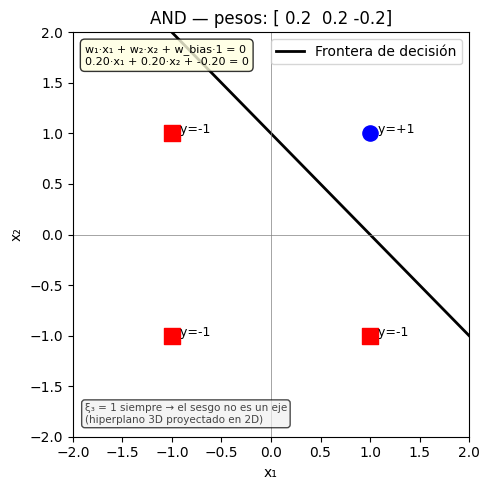

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))

for k in range(p):
    color  = 'blue' if y[k] == 1 else 'red'
    marker = 'o'    if y[k] == 1 else 's'
    ax.scatter(x_original[k,0], x_original[k,1], c=color, marker=marker, s=120, zorder=3)
    ax.annotate(f"  y={int(y[k]):+d}", (x_original[k,0], x_original[k,1]), fontsize=9)
if abs(w_min[1]) > 1e-6:
    x1_vals = np.linspace(-2, 2, 100)
    x2_vals = -(w_min[0] * x1_vals + w_min[2]) / w_min[1]
    ax.plot(x1_vals, x2_vals, 'k-', linewidth=2, label='Frontera de decisión')

ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title(f'{nombre_compuerta} — pesos: {w_min.round(2)}')
ax.legend()

eq_str = (f"w₁·x₁ + w₂·x₂ + w_bias·1 = 0\n"
          f"{w_min[0]:.2f}·x₁ + {w_min[1]:.2f}·x₂ + {w_min[2]:.2f} = 0")

ax.text(0.03, 0.97, eq_str,
        transform=ax.transAxes,
        fontsize=8, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

ax.text(0.03, 0.03,
        "ξ₃ = 1 siempre → el sesgo no es un eje\n(hiperplano 3D proyectado en 2D)",
        transform=ax.transAxes,
        fontsize=7.5, verticalalignment='bottom', color='#444444',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.7))

plt.tight_layout()
plt.show()

### 2DA CONSIGNA

In [ ]:
import numpy as np

i = 0
eta= 0.001
x_original = np.loadtxt('TP1-ej2-Conjunto-entrenamiento.txt')
y = np.loadtxt('TP1-ej2-Salida-deseada.txt')
p =  len(x_original)
cota = 1000
error = 1
error_min = float('inf')

# Creamos una columna de unos con la misma cantidad de filas que x_original (p filas, 1 columna)
bias_column = np.ones((p, 1))

# Concatenamos horizontalmente la matriz x_original con la columna de unos
x = np.hstack((x_original, bias_column)) # x ahora incluye las características originales + la característica de sesgo

w = np.zeros(x.shape[1]) # Inicializamos los pesos (w) a ceros. x.shape[1] ahora es 3.

while error > 0 and i < cota:
  ix = np.random.randint(0, p)
  current_x_features = x[ix]
  h = np.dot(current_x_features, w) #Exitación de la neurona,  ya que x incluye el sesgo. suma ponderada de las características de entrada, incluyendo el sesgo.
  O = h


  # Calcular el término de error para la muestra actual
  error_sample = y[ix] - O

  # Actualizar los pesos (w)
  w = w + eta * error_sample * current_x_features

  # Incrementar el contador de iteraciones
  i += 1

  #Calcular el error global (MSE)
  error = 0
  for j in range(p):
      O_example = np.tanh(np.dot(x[j], w))
      error += (y[j] - O_example) ** 2
  error = error / 2


  # Mantener el mejor resultado (error_min y w_min)
  if error < error_min:
      error_min = error
      w_min = np.copy(w)

### Resultados del Entrenamiento



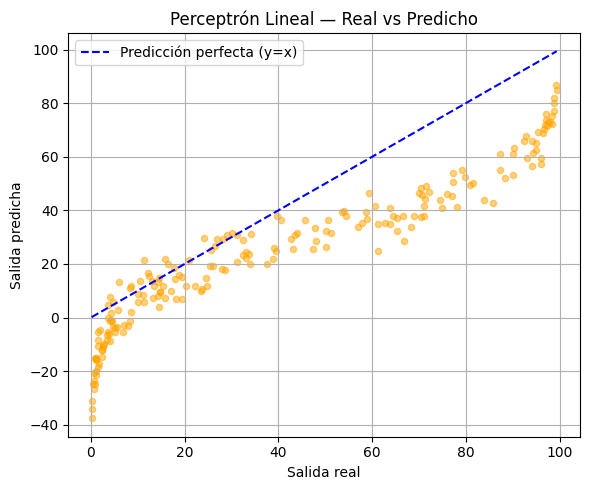

Mejor Error encontrado: 272255.3484929349
Pesos finales (incluyendo sesgo): [ 4.36681921  5.12766426  6.81563081 25.93704545]
Número de iteraciones: 1000


In [ ]:
import matplotlib.pyplot as plt
predicciones = [np.dot(x[k], w_min) for k in range(p)]
plt.figure(figsize=(6, 5))
plt.scatter(y, predicciones, alpha=0.5, color='orange', s=20)
plt.plot([min(y), max(y)], [min(y), max(y)], 'b--', linewidth=1.5, label='Predicción perfecta (y=x)')
plt.title('Perceptrón Lineal — Real vs Predicho')
plt.xlabel('Salida real')
plt.ylabel('Salida predicha')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Mejor Error encontrado: {error_min}")
print(f"Pesos finales (incluyendo sesgo): {w_min}")
print(f"Número de iteraciones: {i}")

### NO LINEAL


In [ ]:
import numpy as np

i = 0
eta= 0.001
x_original = np.loadtxt('TP1-ej2-Conjunto-entrenamiento.txt')

y_raw = np.loadtxt('TP1-ej2-Salida-deseada.txt')
y_min, y_max = y_raw.min(), y_raw.max()
y = 2 * (y_raw - y_min) / (y_max - y_min) - 1

p =  len(x_original)
cota = 10000
error = 1
error_min = float('inf')


# Creamos una columna de unos con la misma cantidad de filas que x_original (p filas, 1 columna)
bias_column = np.ones((p, 1))

# Concatenamos horizontalmente la matriz x_original con la columna de unos
x = np.hstack((x_original, bias_column)) # x ahora incluye las características originales + la característica de sesgo

w = np.zeros(x.shape[1]) # Inicializamos los pesos (w) a ceros. x.shape[1] ahora es 3.

while error > 0 and i < cota:
  ix = np.random.randint(0, p)
  current_x_features = x[ix]
  h = np.dot(current_x_features, w) #Exitación de la neurona,  ya que x incluye el sesgo. suma ponderada de las características de entrada, incluyendo el sesgo.

  O = np.tanh(h) #Función de activación, si h es positiva retorna 1, negativa -1


  # Calcular el término de error para la muestra actual
  error_sample = y[ix] - O

  # Actualizar los pesos (w)
  #Y el Δw tiene un término extra — la derivada de tanh:
  O_grad = 1 - O**2
  w = w + eta * (y[ix] - O) * O_grad * current_x_features


  # Incrementar el contador de iteraciones
  i += 1

  # Calcular el error global (MSE)
  error = 0
  for j in range(p):
      O_example = np.tanh(np.dot(x[j], w))
      error += (y[j] - O_example) ** 2
  error = error / 2

  # Mantener el mejor resultado (error_min y w_min)
  if error < error_min:
      error_min = error
      w_min = np.copy(w)

### RESULTADOS


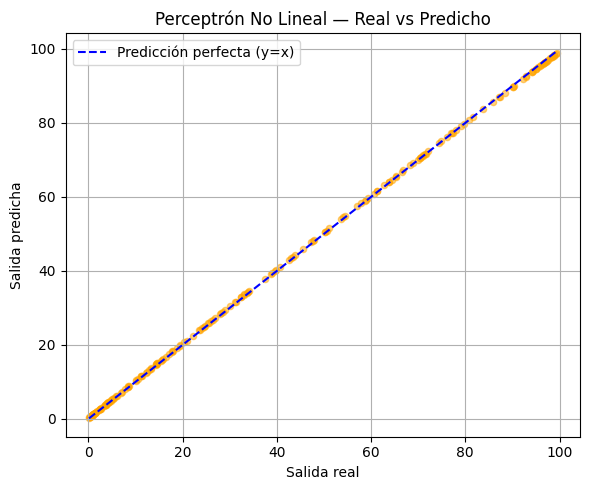

Mejor Error encontrado: 0.00478704111653701
Pesos finales (incluyendo sesgo): [ 0.25024431  0.25077107  0.25014989 -0.23691405]
Número de iteraciones: 10000


In [ ]:



# Predicciones con tanh y desnormalizadas

predicciones = [np.tanh(np.dot(x[k], w_min)) for k in range(p)]

pred_desnorm = [(v + 1) / 2 * (y_max - y_min) + y_min for v in predicciones]

y_real       = [(v + 1) / 2 * (y_max - y_min) + y_min for v in y]

# --- Gráfico 1: Real vs Predicho (el que ya tenías) ---

plt.figure(figsize=(6, 5))

plt.scatter(y_real, pred_desnorm, alpha=0.5, color='orange', s=20)

plt.plot([min(y_real), max(y_real)], [min(y_real), max(y_real)],

         'b--', linewidth=1.5, label='Predicción perfecta (y=x)')

plt.title('Perceptrón No Lineal — Real vs Predicho')

plt.xlabel('Salida real')

plt.ylabel('Salida predicha')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

### 2a: Generalización

In [ ]:
import numpy as np

i = 0
eta= 0.001
x_original = np.loadtxt('TP1-ej2-Conjunto-entrenamiento.txt')
y_raw = np.loadtxt('TP1-ej2-Salida-deseada.txt')
y_min, y_max = y_raw.min(), y_raw.max()
y = 2 * (y_raw - y_min) / (y_max - y_min) - 1

split = int(0.8 * len(x_original))
x_train = x_original[:split]
y_train = y[:split]
x_test = x_original[split:]
y_test = y[split:]

x_original = x_train
y = y_train
p = len(x_train)

cota = 10000
error = 1
error_min = float('inf')


# Creamos una columna de unos con la misma cantidad de filas que x_original (p filas, 1 columna)
bias_column = np.ones((p, 1))

# Concatenamos horizontalmente la matriz x_original con la columna de unos
x = np.hstack((x_original, bias_column)) # x ahora incluye las características originales + la característica de sesgo

w = np.zeros(x.shape[1]) # Inicializamos los pesos (w) a ceros. x.shape[1] ahora es 3.

while error > 0 and i < cota:
  ix = np.random.randint(0, p)
  current_x_features = x[ix]
  h = np.dot(current_x_features, w) #Exitación de la neurona,  ya que x incluye el sesgo. suma ponderada de las características de entrada, incluyendo el sesgo.
  O = np.tanh(h) #Función de activación, si h es positiva retorna 1, negativa -1


  # Calcular el término de error para la muestra actual
  error_sample = y[ix] - O

  # Actualizar los pesos (w)
  O_grad = 1 - O**2
  w = w + eta * (y[ix] - O) * O_grad * current_x_features

  # Incrementar el contador de iteraciones
  i += 1

  # Calcular el error global (MSE)
  error = 0
  for j in range(p):
      O_example = np.dot(x[j], w)
      error += (y[j] - O_example) ** 2
  error = error / 2

  # Mantener el mejor resultado (error_min y w_min)
  if error < error_min:
      error_min = error
      w_min = np.copy(w)


error_test = 0
for k in range(len(x_test)):
    h_test = np.dot(np.append(x_test[k], 1), w_min)
    O_test = np.tanh(h_test)
    error_test += (y_test[k] - O_test) ** 2
error_test = error_test / 2

print(f"Error en entrenamiento (MSE): {error_min}")
print(f"Error en test (MSE): {error_test}")


Error en entrenamiento (MSE): 3.6837367478058827
Error en test (MSE): 1.0597759669339246


### ENTRENAMIENTO Y TEST


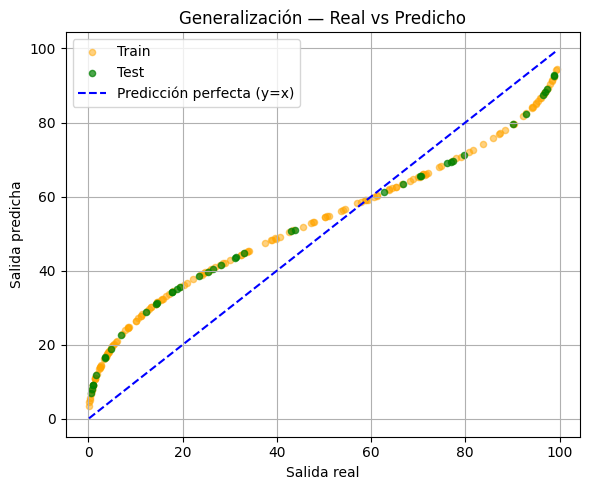

In [ ]:
import matplotlib.pyplot as plt

def desnorm(vals):
    return [(v + 1) / 2 * (y_max - y_min) + y_min for v in vals]

predicciones_train = [np.tanh(np.dot(x[k], w_min)) for k in range(len(x))]
predicciones_test  = [np.tanh(np.dot(np.append(x_test[k], 1), w_min)) for k in range(len(x_test))]

y_train_real = desnorm(list(y))
y_test_real  = desnorm(list(y_test))
pred_train   = desnorm(predicciones_train)
pred_test    = desnorm(predicciones_test)

todos_reales = y_train_real + y_test_real
lim = [min(todos_reales), max(todos_reales)]

plt.figure(figsize=(6, 5))
plt.scatter(y_train_real, pred_train, alpha=0.5, color='orange', s=20, label='Train')
plt.scatter(y_test_real,  pred_test,  alpha=0.7, color='green',  s=20, label='Test')
plt.plot(lim, lim, 'b--', linewidth=1.5, label='Predicción perfecta (y=x)')
plt.title('Generalización — Real vs Predicho')
plt.xlabel('Salida real')
plt.ylabel('Salida predicha')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()